# How to train a neural network to flag spam

## Abstract

This is an AI pipeline that demonstrates the use of advanced AI tools used to classify messages as 'spam' or 'not spam'. We will be using the Kaggle dataset ([sms-spam-collection-dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)) to train the model to classify different test messages. Python packages such as pandas, PyTorch, and numpy will be used to pre-process and train a model. We will use MatPlotLib to visualise the results as well as visual correlations between data. We will cleanse and tokenise our data so that it can be processed by our neural network.

## Set up

### Required dependencies

You can find all required dependencies in the [requriements.txt](./requirements.txt)

### Virtual enviroment

This is because you want to isolate dependencies into its own enviroment so you don't install unneccessary dependencies outside of the virtual env.

For MacOSX

```bash
python3 -m venv venv
source venv/bin/activate
pip3 install -r ./requirements.txt
```

For Windows PowerShell

```powershell
python -m venv venv
venv\Scripts\Activate.ps1
pip install -r requirements.txt
```

For Windows cmd

```cmd
python -m venv venv
venv\Scripts\activate.bat
pip install -r requirements.txt
```

## Importing dataset

In [1]:
import pandas as pd

# Latin1 encoding 
df = pd.read_csv("./spam.csv", encoding='latin1')

# Remove any empty rows
df = df.dropna(how="any", axis=1)
df.columns = ["label","message"]
# Binary values for ham (0) and spam (1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Label distribution

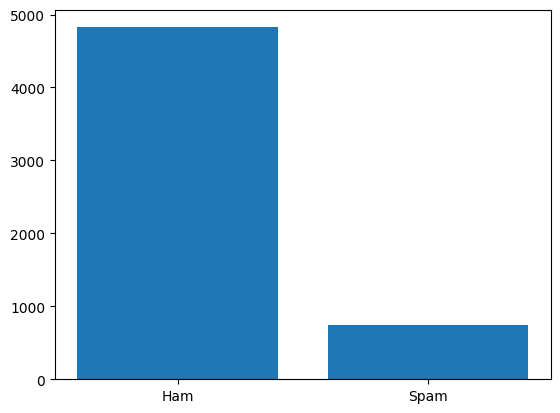

In [2]:
import matplotlib.pyplot as plt
import numpy as np

label_distribution = df.groupby("label")["label"].agg("count").values
label_distribution

x = np.array(["Ham","Spam"])
y = np.array(label_distribution)

plt.bar(x,y)
plt.show()

## Find correlation between length of message and label

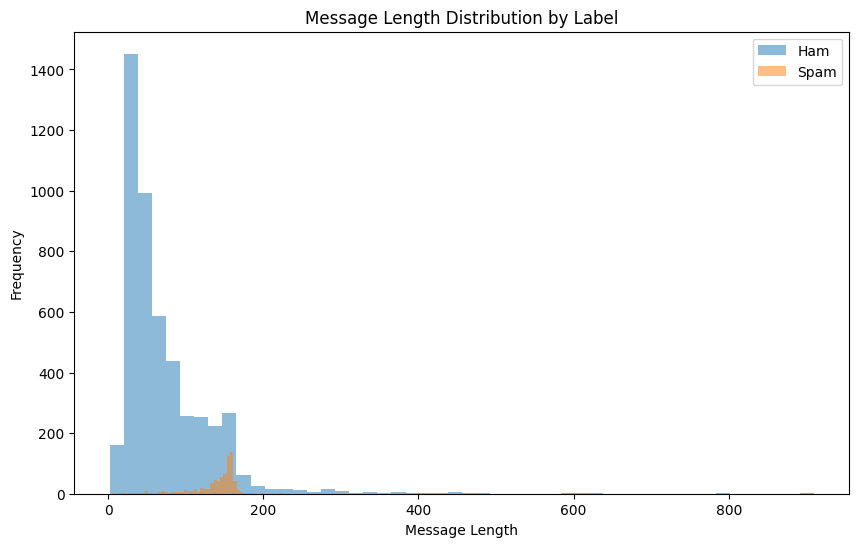

In [3]:
df['message_len'] = df['message'].astype(str).map(len)
df.head()

df.groupby("label")["message_len"].describe()

plt.figure(figsize=(10,6))

# Ham
plt.hist(df[df["label"] == 0]["message_len"], 
         bins=50, alpha=0.5, label="Ham")

# Spam
plt.hist(df[df["label"] == 1]["message_len"], 
         bins=50, alpha=0.5, label="Spam")

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Message Length Distribution by Label")
plt.legend()
plt.show()

### Normalized as the dataset is imbalanced

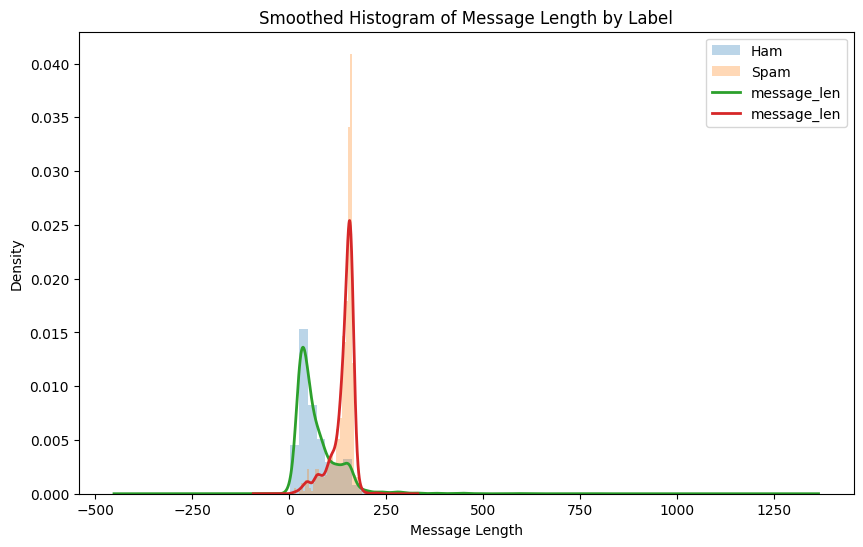

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ham = df[df["label"] == 0]["message_len"]
spam = df[df["label"] == 1]["message_len"]

# Histograms
plt.hist(ham, bins=40, density=True, alpha=0.3, label="Ham")
plt.hist(spam, bins=40, density=True, alpha=0.3, label="Spam")

# KDE lines
ham.plot(kind="kde", linewidth=2)
spam.plot(kind="kde", linewidth=2)

plt.xlabel("Message Length")
plt.ylabel("Density")
plt.title("Smoothed Histogram of Message Length by Label")
plt.legend()
plt.show()

## Preprocessing data

### Text cleaning

In [5]:
# text cleaning as from source [1]

import re
import string

def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text


In [6]:
df['message_clean'] = df['message'].apply(clean_text)
df.head()

,label,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in a wkly comp to win fa cup final...
3,0,U dun say so early hor... U c already then say...,49,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah i dont think he goes to usf he lives aroun...


In [7]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# stopwords processing as from source [1]

stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text
    
df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/costjl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts m...
3,0,U dun say so early hor... U c already then say...,49,dun say early hor already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though


### Splitting training and testing data

In [8]:
from sklearn.model_selection import train_test_split

X = df["message_clean"]
y = df["label"]
lengths = df["message_len"]

X_train, X_test, y_train, y_test , len_train, len_test = train_test_split(
    X, 
    y,
    lengths,
    test_size=0.2,      # 20% test
    random_state=42,    # reproducibility
    stratify=y          # IMPORTANT for spam/ham balance
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


In [9]:
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encoded = tokenizer(
    list(X_train),
    padding = True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

test_encoded = tokenizer(
    list(X_test),
    padding = True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

/Users/costjl/Documents/advanced ai cw/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
train_lengths = torch.tensor(len_train.values, dtype=torch.float32)
test_lengths = torch.tensor(len_test.values, dtype=torch.float32)

In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_encoded["input_ids"],train_lengths.unsqueeze(1), y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


test_dataset = TensorDataset(test_encoded["input_ids"], test_lengths.unsqueeze(1), y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32)

In [12]:
import torch.nn as nn

class SpamRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2 + 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, msg_len):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        combined = torch.cat([hidden, msg_len], dim=1)
        out = self.fc(combined)
        return self.sigmoid(out).squeeze()

In [13]:
vocab_size = tokenizer.vocab_size

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpamRNN(vocab_size=vocab_size).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

for epoch in range(10):
    model.train()
    epoch_loss = 0
    for X_batch, len_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        len_batch = len_batch.to(device)
        y_batch = y_batch.to(device).float()
        
        optimizer.zero_grad()
        outputs = model(X_batch, len_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1 Loss: 0.3467
Epoch 2 Loss: 0.0910
Epoch 3 Loss: 0.0495
Epoch 4 Loss: 0.0325
Epoch 5 Loss: 0.0173
Epoch 6 Loss: 0.0109
Epoch 7 Loss: 0.0055
Epoch 8 Loss: 0.0026
Epoch 9 Loss: 0.0021
Epoch 10 Loss: 0.0020


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, len_batch, y_batch in test_loader:   # now each batch has 3 items
        X_batch = X_batch.to(device)
        len_batch = len_batch.to(device)
        y_batch = y_batch.to(device).float()

        outputs = model(X_batch, len_batch)          # pass both inputs
        predictions = (outputs > 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9812


In [17]:
# Example new message
new_message = "Hey how are you finding work today?"

# Tokenize like before
encoding = tokenizer(
    [new_message],
    padding="max_length",
    truncation=True,
    max_length=train_encoded["input_ids"].shape[1],  # same seq_len as training
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)

# Compute message length (same as your length column)
msg_len = torch.tensor([[len(new_message.split())]], dtype=torch.float32)  # shape (1,1)


# Forward pass
model.eval()
with torch.no_grad():
    output = model(input_ids, msg_len)  # pass both inputs
    prediction = (output > 0.5).float()

# Interpret result
if prediction.item() == 1:
    print("Spam")
else:
    print("Ham")

Ham


### Dataset

The dataset comes from [Kaggle.com](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)

It is a collection of SMS messages which are classified as 'spam' or 'ham' (not spam)

The dataset is found in the [spam.csv](./spam.csv)